In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns

from dotenv import load_dotenv
load_dotenv()


PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

# Cell type variable annotation to use in this analysis
CT_FOR_DEG_VARIABLE = "ct_for_deg"  # "Group_name", "spn_type"
# Sample variable
SAMPLE_VARIABLE = "donor_id"
# Variable to test if differentially expressed
CONTRAST_VARIABLE = "condition"
# Level of contrast variable to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrast variable to use as stimulated
CONTRAST_STIM = "XDP"
# Age column
AGE = "age_of_death"
ZONE_COL = "zone"

# Covariates to use for statistical test
COVARIATES_FOR_DEG = ["sex", "pct_counts_mt"]  # "frac_intronic", "cohort"

# Library size column for nebula
LIBRARY_SIZE_COL = "total_counts"

# Load

In [3]:
ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
adata = sc.read_h5ad(ADATA_PATH, backed="r")
adata.obs.columns

###########################
#ATTENTION: use genenames for DEG
adata.var.index = adata.var["gene_symbol"]
###########################

adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].str.replace(" ", "_")


# D1 Matrix zone6

In [4]:
# Selct ct
adata = adata[
        (adata.obs[CT_FOR_DEG_VARIABLE] == "Matrix_D1") & # only QC cells tat are matrix
        (adata.obs["zone"].notna()) # only cells with zone annotation
    ].to_memory().copy()
adata

AnnData object with n_obs × n_vars = 11406 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

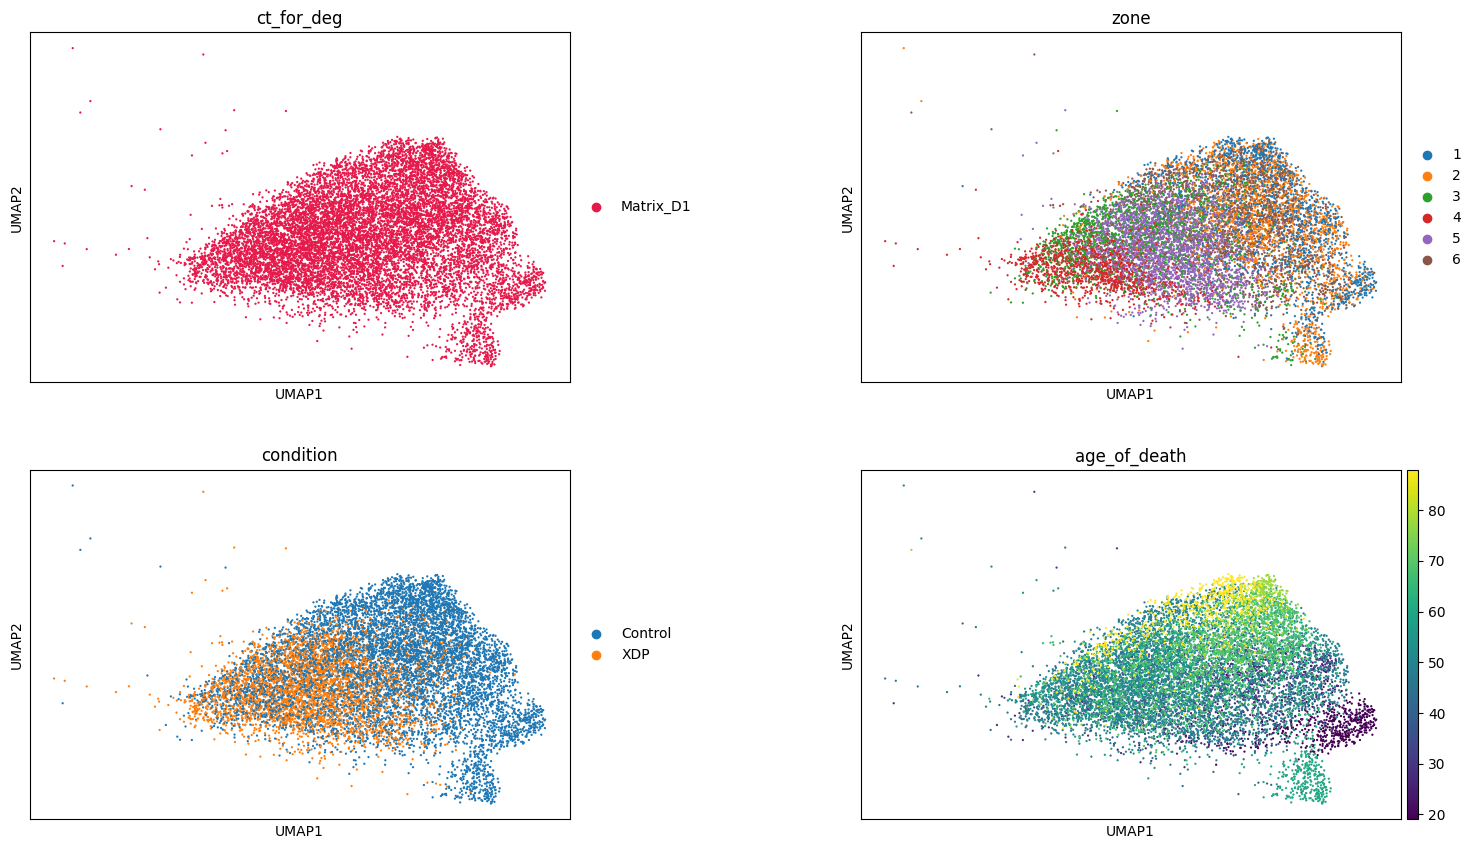

In [5]:
sc.pl.umap(adata, color=[CT_FOR_DEG_VARIABLE, "zone", CONTRAST_VARIABLE, AGE], wspace=0.4, ncols=2)

In [ ]:
# read bican
bican = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/d1_cleaner_v3_raw_dv_wm_labeled.h5ad", backed="r")

# X contains raw counts

# Rename columns to match NucSeq conventions
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})
bican.obs[CONTRAST_VARIABLE] = CONTRAST_BASELINE
bican_cov = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"]

## Find "new deteed geens" using bican

In [ ]:
def merge_adata(adata_list):

    # Step 1: Check gene overlap
    gene_sets    = [set(a.var_names) for a in adata_list]
    common_genes = set.intersection(*gene_sets)
    all_genes    = set.union(*gene_sets)
    print(f"\n[GENES] Common: {len(common_genes)} | Total: {len(all_genes)} | Only-in-some: {len(all_genes) - len(common_genes)}")

    # Save var info from any adata BEFORE concat (they all have the same genes).
    # sc.concat silently drops .var columns when doing join='inner',
    # so we can take whichever adata we want since we are doing an inner join.
    var_info = adata_list[0].var[["gene_symbol"]].copy()

    # Use intersection of genes across all adatas
    adata_combined_intersection = sc.concat(
        adata_list,
        join='inner',      # Keep only common genes
        label=None,        # Name of the new column added to .obs
        keys=None,         # Values put in that column, one per adata
        index_unique=None  # obs_names are already unique
    )

    # Restore var info for the common genes
    adata_combined_intersection.var = var_info.loc[adata_combined_intersection.var_names]

    print(f"Combined shape (intersection): {adata_combined_intersection.shape}")
    print(f"  Cells: {adata_combined_intersection.n_obs}")
    print(f"  Genes: {adata_combined_intersection.n_vars}")

    del adata_list
    print(adata_combined_intersection)

    # ── SANITY CHECKS ─────────────────────────────────────────────────────────────
    assert adata_combined_intersection.obs_names.is_unique, "ERROR: obs_names are not unique!"

    return adata_combined_intersection

In [ ]:
for zone in adata.obs["zone"].unique():

    zone = "4"
    print(zone)

    # Subset to this zone
    adata_zone = adata[adata.obs[ZONE_COL] == zone].copy()
    bican_zone = bican[bican.obs[ZONE_COL] == int(zone)].to_memory().copy()

    # Remove samples with too few cells
    N = 20
    adata_zone = adata_zone[adata_zone.obs[SAMPLE_VARIABLE].isin(adata_zone.obs[SAMPLE_VARIABLE].value_counts()[adata_zone.obs[SAMPLE_VARIABLE].value_counts() >= N].index)]
    bican_zone = bican_zone[bican_zone.obs[SAMPLE_VARIABLE].isin(bican_zone.obs[SAMPLE_VARIABLE].value_counts()[bican_zone.obs[SAMPLE_VARIABLE].value_counts() >= N].index)]

    print(bican_zone)
    print(bican_zone.obs[SAMPLE_VARIABLE].nunique())
    print(adata_zone.obs[SAMPLE_VARIABLE].nunique())

    results = find_derepressed_genes(
        bican_zone,  # HEALTHY CELLS ONLY
        AGE,
        counts_col           = LIBRARY_SIZE_COL,
        other_covariate_cols = bican_cov,
        threshold            = 0.02,
    )

    break

In [10]:
import numpy as np
import pandas as pd
import scipy.sparse
import re
from statsmodels.stats.multitest import multipletests


def find_derepressed_genes(
    adata,

    # --- Required column names in adata.obs ---
    age_col          = "age",
    donor_col        = "donor_id",

    # --- Per-cell total UMI counts column in adata.obs ---
    # Used to compute mean log(UMI) per donor as a sequencing depth covariate.
    # The function computes the mean itself from the subsampled cells of each
    # donor — you just tell it which per-cell column to use.
    # Set to None to auto-detect from common names (n_counts, total_counts...).
    counts_col       = None,

    # --- Other covariates (sex, ancestry PCs) ---
    other_covariate_cols = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"],

    # --- Detection threshold ---
    threshold        = 0.05,

    # --- Age group definitions ---
    young_quantile   = 0.25,
    old_quantile     = 0.75,

    # --- Quality filters ---
    min_cells        = 30,
    fdr_threshold    = 0.05,
    exclude_pattern  = r"^MT-|^RPS\d|^RPL\d|^HB[^P]",

    # --- Permutation settings ---
    n_perm           = 10000,
    seed             = 42,
):
    """
    Identify genes that are silenced in young donors and significantly
    re-expressed (de-repressed) with age.

    Exactly mirrors derepression_threshold_forward.py.

    Parameters
    ----------
    adata                : AnnData — cells x genes, raw counts in adata.X.
                           Filter to your cell type and zone BEFORE calling.
    age_col              : str  — per-cell donor age column in adata.obs
    donor_col            : str  — per-cell donor ID column in adata.obs
    counts_col           : str or None
                           Per-CELL total UMI count column in adata.obs
                           (e.g. "n_counts", "total_counts").
                           The function computes mean log(counts) per donor
                           from the subsampled cells itself.
                           None = auto-detect.
    other_covariate_cols : list — sex, ancestry PCs (no squared term added)
    threshold            : float — max detection rate in young donors (2% default)
    young_quantile       : float — age quantile for "young" group (default 0.25)
    old_quantile         : float — age quantile for "old" group   (default 0.75)
    min_cells            : int   — drop donors with fewer cells
    fdr_threshold        : float — BH p-value cutoff
    exclude_pattern      : str   — regex of genes to always exclude
    n_perm               : int   — permutation count
    seed                 : int   — random seed

    Returns
    -------
    results : pd.DataFrame, one row per candidate gene:
        gene           — gene name
        young_detect   — mean detection rate in young donors
        old_detect     — mean detection rate in old donors
        delta_detect   — old_detect - young_detect
        exceeds_in_old — True if old_detect > threshold
        obs_beta       — age slope after covariate removal
        perm_pval      — one-sided empirical p-value (raw, not FDR corrected)
        perm_padj      — BH-adjusted p-value
        significant    — True if perm_padj < fdr_threshold AND beta > 0
    """

    rng = np.random.RandomState(seed)

    # ------------------------------------------------------------------
    # 0. Validate inputs and auto-detect counts column
    # ------------------------------------------------------------------
    check_cols = [age_col, donor_col] + other_covariate_cols
    missing = [c for c in check_cols if c not in adata.obs.columns]
    if missing:
        raise ValueError(f"Columns not found in adata.obs: {missing}")

    # Auto-detect per-cell counts column if not specified
    if counts_col is None:
        _candidates = ["n_counts", "total_counts", "nCounts", "nUMI",
                       "n_umi", "total_UMI"]
        _found = [c for c in _candidates if c in adata.obs.columns]
        if not _found:
            raise ValueError(
                f"Could not auto-detect counts column. Tried: {_candidates}\n"
                f"Available adata.obs columns: {list(adata.obs.columns)}\n"
                f"Pass counts_col='your_column' explicitly."
            )
        counts_col = _found[0]
        print(f"Auto-detected counts column: '{counts_col}'")
    elif counts_col not in adata.obs.columns:
        raise ValueError(
            f"counts_col='{counts_col}' not found in adata.obs.\n"
            f"Available: {list(adata.obs.columns)}"
        )

    # ------------------------------------------------------------------
    # 1. Prepare sparse count matrix
    # ------------------------------------------------------------------
    X = adata.X
    if not scipy.sparse.issparse(X):
        X = scipy.sparse.csr_matrix(X)
    elif not scipy.sparse.isspmatrix_csr(X):
        X = X.tocsr()

    donors_array  = adata.obs[donor_col].values
    counts_array  = adata.obs[counts_col].values.astype(float)  # per-cell UMI counts
    gene_names    = adata.var_names.tolist()
    n_genes       = len(gene_names)

    # ------------------------------------------------------------------
    # 2. Filter donors by minimum cell count
    # ------------------------------------------------------------------
    unique_donors, cell_counts = np.unique(donors_array, return_counts=True)
    donor_ncells = dict(zip(unique_donors, cell_counts))
    valid_donors = [d for d, n in donor_ncells.items() if n >= min_cells]
    n_dropped    = len(donor_ncells) - len(valid_donors)

    if n_dropped:
        print(f"Dropped {n_dropped} donors with < {min_cells} cells")
    if not valid_donors:
        raise ValueError("No donors passed the minimum cell count filter")

    # ------------------------------------------------------------------
    # 3. Downsample all donors to the same number of cells
    #
    #    A donor with 3000 cells detects more genes than one with 200 cells
    #    purely due to sampling, not biology. Equalising cell counts removes
    #    this confound before computing detection rates.
    # ------------------------------------------------------------------
    min_n = min(donor_ncells[d] for d in valid_donors)
    print(f"{len(valid_donors)} valid donors — downsampling each to {min_n} cells")

    # ------------------------------------------------------------------
    # 4. Compute per-donor detection rates AND mean log UMI
    #
    #    For each donor:
    #      - subsample min_n cells
    #      - detection rate = fraction of subsampled cells with >= 1 count
    #      - mean_log_umi   = mean of log(per-cell UMI) across subsampled cells
    #
    #    mean_log_umi is computed from the SAME subsampled cells as detection,
    #    exactly as in the original script.
    # ------------------------------------------------------------------
    detect_matrix = np.zeros((n_genes, len(valid_donors)), dtype=np.float32)
    mean_log_umi  = np.zeros(len(valid_donors),            dtype=np.float64)
    meta_rows     = []

    for j, donor in enumerate(valid_donors):

        # All cell indices for this donor
        cell_idx = np.where(donors_array == donor)[0]

        # Subsample to min_n
        if len(cell_idx) > min_n:
            cell_idx = rng.choice(cell_idx, size=min_n, replace=False)

        # Detection rate: fraction of subsampled cells with >= 1 count per gene
        detected             = np.asarray((X[cell_idx, :] > 0).sum(axis=0)).ravel()
        detect_matrix[:, j]  = detected / min_n

        # Mean log UMI across subsampled cells (log1p to handle zeros safely)
        mean_log_umi[j] = np.log1p(counts_array[cell_idx]).mean()

        # One row of obs metadata per donor (for age, sex, PCs)
        meta_rows.append(adata.obs[donors_array == donor].iloc[0])

    meta     = pd.DataFrame(meta_rows).reset_index(drop=True)
    n_donors = len(valid_donors)

    # ------------------------------------------------------------------
    # 5. Identify young and old donor masks
    # ------------------------------------------------------------------
    ages       = meta[age_col].values.astype(float)
    q_young    = np.quantile(ages, young_quantile)
    q_old      = np.quantile(ages, old_quantile)
    young_mask = ages <= q_young
    old_mask   = ages >= q_old

    print(f"Young (age <= {q_young:.0f}): {young_mask.sum()} donors | "
          f"Old   (age >= {q_old:.0f}):   {old_mask.sum()} donors")

    # Mean detection rate across young / old donors — used for candidate selection
    young_detect = detect_matrix[:, young_mask].mean(axis=1)   # (n_genes,)
    old_detect   = detect_matrix[:, old_mask].mean(axis=1)     # (n_genes,)

    # ------------------------------------------------------------------
    # 6. Select candidate genes
    #
    #    Candidate = silent in young (mean detection <= threshold)
    #              + not a housekeeping/artifact gene
    # ------------------------------------------------------------------
    exclude_re   = re.compile(exclude_pattern)
    exclude_mask = np.array([bool(exclude_re.match(g)) for g in gene_names])

    candidate_mask = (young_detect <= threshold) & (~exclude_mask)
    n_candidates   = candidate_mask.sum()
    print(f"Candidate genes silent in young (threshold={threshold*100:.1f}%): "
          f"{n_candidates}")

    if n_candidates == 0:
        raise ValueError(
            "No candidate genes found. Try:\n"
            "  - Increasing threshold (e.g. 0.05)\n"
            "  - Reducing min_cells to keep more donors\n"
            "  - Checking adata.X contains raw counts (not normalised)"
        )

    detect_cand = detect_matrix[candidate_mask, :]             # (n_cand, n_donors)
    cand_genes  = [g for g, m in zip(gene_names, candidate_mask) if m]

    # ------------------------------------------------------------------
    # 7. Build covariate matrix
    #
    #    Exactly mirrors original script:
    #      [intercept, depth, depth², sex, PC1, PC2, PC3, PC4, PC5]
    #
    #    depth  = mean_log_umi computed above from subsampled cells
    #    depth² = always included (captures non-linear depth effects)
    # ------------------------------------------------------------------
    cov_arrays = [
        np.ones(n_donors),  # intercept
        mean_log_umi,        # sequencing depth (linear)
        mean_log_umi ** 2,   # sequencing depth (squared) — always added
    ]

    for col in other_covariate_cols:
        raw = meta[col].values
        try:
            vals = raw.astype(float)
        except (ValueError, TypeError):
            # Encode string columns (e.g. 'F'/'M' -> 0/1)
            unique_vals = sorted(set(raw))
            mapping     = {v: i for i, v in enumerate(unique_vals)}
            vals        = np.array([mapping[v] for v in raw], dtype=float)
            print(f"Encoded '{col}': {mapping}")
        cov_arrays.append(vals)

    X_cov = np.column_stack(cov_arrays)                        # (n_donors, n_cov)
    Q, _  = np.linalg.qr(X_cov, mode="reduced")               # (n_donors, n_cov)

    # ------------------------------------------------------------------
    # 8. FWL residualisation
    #
    #    Remove all covariate effects from both age and detection rates
    #    before computing the age slope.
    # ------------------------------------------------------------------
    age_resid    = ages - Q @ (Q.T @ ages)                     # (n_donors,)
    ss_age       = np.sum(age_resid ** 2)

    if ss_age < 1e-12:
        # Diagnose which covariate is eating age variance
        print("\n--- COLLINEARITY DIAGNOSTIC ---")
        print(f"Age vector (first 10): {ages[:10]}")
        print(f"Age variance before residualisation: {np.var(ages):.4f}")
        for col_name, col_vec in zip(
            ["intercept", "mean_log_umi", "mean_log_umi²"] + other_covariate_cols,
            cov_arrays
        ):
            r = np.corrcoef(ages, col_vec)[0, 1]
            print(f"  corr(age, {col_name}) = {r:.4f}")
        print("-------------------------------\n")
        raise ValueError(
            "No age variance after residualisation.\n"
            "Most likely cause: COVARIATES_FOR_DEG contains age itself, "
            "or a variable perfectly predicted by age.\n"
            "Check the correlations printed above and remove the offending covariate."
        )

    detect_resid = detect_cand - (Q @ (Q.T @ detect_cand.T)).T  # (n_cand, n_donors)
    obs_betas    = (detect_resid @ age_resid) / ss_age            # (n_cand,)

    # ------------------------------------------------------------------
    # 9. Permutation test — one-sided (detection increases with age)
    # ------------------------------------------------------------------
    print(f"Running {n_perm} permutations ...", flush=True)

    perm_indices   = np.column_stack([rng.permutation(n_donors)
                                      for _ in range(n_perm)])   # (n_donors, n_perm)
    age_perm_mat   = ages[perm_indices]                           # (n_donors, n_perm)
    age_resid_perm = age_perm_mat - Q @ (Q.T @ age_perm_mat)     # (n_donors, n_perm)
    ss_perm        = np.sum(age_resid_perm ** 2, axis=0)          # (n_perm,)

    beta_perm_mat  = (detect_resid @ age_resid_perm) / ss_perm    # (n_cand, n_perm)

    perm_counts    = np.sum(beta_perm_mat >= obs_betas[:, np.newaxis], axis=1)
    perm_pvals     = (1 + perm_counts) / (1 + n_perm)

    # ------------------------------------------------------------------
    # 10. BH FDR correction
    # ------------------------------------------------------------------
    _, perm_padjs, _, _ = multipletests(perm_pvals, method="fdr_bh")

    # ------------------------------------------------------------------
    # 11. Assemble results
    # ------------------------------------------------------------------
    results = pd.DataFrame({
        "gene"           : cand_genes,
        "young_detect"   : young_detect[candidate_mask],
        "old_detect"     : old_detect[candidate_mask],
        "delta_detect"   : old_detect[candidate_mask] - young_detect[candidate_mask],
        "exceeds_in_old" : old_detect[candidate_mask] > threshold,
        "obs_beta"       : obs_betas,
        "perm_pval"      : perm_pvals,    # raw — use if FDR is too strict
        "perm_padj"      : perm_padjs,    # BH corrected
        "significant"    : (perm_padjs < fdr_threshold) & (obs_betas > 0),
    }).sort_values("obs_beta", ascending=False).reset_index(drop=True)

    n_sig        = results["significant"].sum()
    n_sig_exceed = (results["significant"] & results["exceeds_in_old"]).sum()
    print(f"Significant (padj < {fdr_threshold}): {n_sig}")
    print(f"  of which exceed threshold in old:   {n_sig_exceed}")
    print(f"\nTo be more lenient:")
    print(f"  results[results['perm_pval'] < 0.05]         # skip FDR correction")
    print(f"  results[results['perm_padj'] < 0.10]         # relax FDR to 10%")
    print(f"  re-run with threshold=0.05, min_cells=10     # more candidates")

    return results


## Ucell for gene scores

In [12]:
adata_zone.X = adata_zone.layers["counts"]
sc.pp.normalize_total(adata_zone, target_sum=1e4)
sc.pp.log1p(adata_zone)
adata_zone.layers["log1p_norm"] = adata_zone.X.copy()
adata_zone.X = adata_zone.layers["counts"]

bican_zone.X = bican_zone.layers["counts"]
sc.pp.normalize_total(bican_zone, target_sum=1e4)
sc.pp.log1p(bican_zone)
bican_zone.layers["log1p_norm"] = bican_zone.X.copy()
bican_zone.X = bican_zone.layers["counts"]

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:629: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_600955/1347292454.py:1: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_zone.X = adata_zone.layers["counts"]
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [13]:
full_adata = merge_adata([adata_zone, bican_zone])



[GENES] Common: 35563 | Total: 41138 | Only-in-some: 5575
Combined shape (intersection): (89719, 35563)
  Cells: 89719
  Genes: 35563
AnnData object with n_obs × n_vars = 89719 × 35563
    obs: 'donor_id', 'total_counts', 'cohort', 'condition', 'sex', 'age_of_death', 'zone'
    var: 'gene_symbol'
    layers: 'counts', 'log1p_norm'


In [15]:
full_adata.obs.groupby("donor_id").size()

/tmp/ipykernel_600955/3849850766.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_adata.obs.groupby("donor_id").size()


donor_id
MD6366         115
MD6417         189
MD6424         175
MD6429          36
MD6432         531
              ... 
UMBEB23073     242
UMBEB23076     508
UMBEB23083     151
UMBEB23100     336
UMBEB24009    1892
Length: 162, dtype: int64

In [16]:
import decoupler as dc
import pandas as pd

sig_genes = results[results["significant"]]["gene"].tolist()

# Build the gene set dataframe decoupler expects
net = pd.DataFrame({
    "source": "derepressed",
    "target": sig_genes,
    "weight": 1.0,
})

# Run UCell
dc.mt.aucell(
    data=full_adata,          # AnnData (log-normalized, e.g. after normalize_total + log1p)
    net=net,             # DataFrame with 'source' and 'target' columns
    tmin=3,              # lower if your gene sets are small (default 5)
    n_up=full_adata.n_vars // 2,           # top N genes used for AUC; None = top 5% automatically
    layer="log1p_norm",          # use a specific adata.layers key, e.g. "log1p"
    raw=False,           # set True only if you want adata.raw
    bsize=250000,        # reduce if running out of memory
    verbose=True,        # handy to see progress
)

# Add score to adata.obs
scores = full_adata.obsm["score_aucell"]
full_adata.obs["derepressed_score"] = scores["derepressed"].values
full_adata.obs["derepressed_score"].plot.hist(bins=30)  

2026-03-12 22:56:40 | [INFO] aucell - Running aucell
2026-03-12 22:56:45 | [INFO] Extracted omics mat with 89719 rows (observations) and 35563 columns (features)
2026-03-12 22:56:50 | [WARNING] 774 features of mat are empty, they will be removed
2026-03-12 22:57:10 | [INFO] Network has 74 unique features and 1 unique sources
2026-03-12 22:57:10 | [INFO] aucell - calculating 1 AUCs for 34789 targets across 89719 observations, categorizing features at rank=17781


  0%|          | 0/89719 [00:00<?, ?it/s]

KeyboardInterrupt: 

<Axes: ylabel='Frequency'>

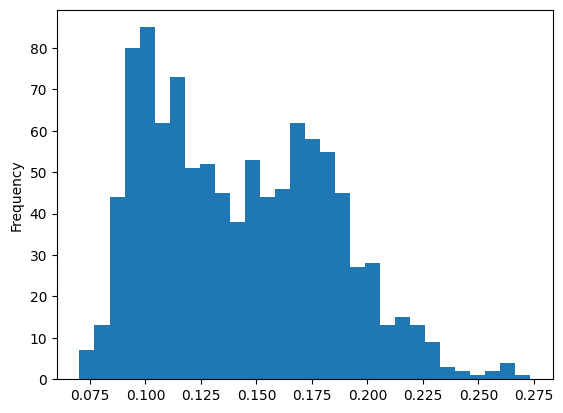

In [ ]:
full_adata.obs["derepressed_score"].plot.hist(bins=30)  

In [ ]:
summary = (
    full_adata.obs
    .groupby(SAMPLE_VARIABLE)
    .agg(
        pct90_derepressed = ("derepressed_score", lambda x: np.percentile(x, 90)),
        age               = (AGE, "first"),
        median_umi        = (LIBRARY_SIZE_COL, "median"),
        condition         = (CONTRAST_VARIABLE, "first"),
    )
    .reset_index()
)

display(summary)

/tmp/ipykernel_548347/2901636069.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("donor_id")


,donor_id,pct90_derepressed,age,median_umi,condition
0,SCF-18-003,0.204121,41.0,35295.5,XDP
1,SCF-18-006,0.200532,51.0,36586.5,XDP
2,SCF-19-018,0.224234,40.0,24820.0,XDP
3,SCF-19-020,0.168294,51.0,91185.5,XDP
4,SCF-20-023,0.201064,41.0,30711.0,XDP
5,SCF-20-025,0.204639,54.0,30957.0,XDP
6,SCF-21-030,0.221115,43.0,30071.0,XDP
7,SCF-22-044,0.156245,50.0,128251.0,XDP
8,SCF-22-045,0.117721,48.0,172314.5,XDP
9,SCF-22-058CF,0.235568,66.0,33565.0,Control


## OLS

In [14]:
import statsmodels.formula.api as smf

# model = smf.ols("pct90_derepressed ~ age + condition + median_umi", data=summary).fit()
# """
# XDP and Control donors may differ in age distribution. If XDP donors tend to be older, any XDP-related increase in score would look like an aging effect. Adding condition separates the two.
# """
# print(model.summary())

# # Partial r for age specifically, controlling for condition and UMI
# resid_age   = smf.ols("age ~ condition + median_umi",               data=summary).fit().resid
# resid_score = smf.ols("pct90_derepressed ~ condition + median_umi", data=summary).fit().resid
# partial_r   = np.corrcoef(resid_age, resid_score)[0, 1]
# print(f"Partial r (age ~ derepressed, controlling for condition + UMI): {partial_r:.3f}")

In [174]:
# Encode condition numerically for interaction term
summary["is_xdp"] = (summary["condition"] == "XDP").astype(int)

model = smf.ols(
    "pct90_derepressed ~ age * is_xdp + median_umi",
    data=summary
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      pct90_derepressed   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     67.74
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.03e-09
Time:                        22:32:15   Log-Likelihood:                 67.881
No. Observations:                  20   AIC:                            -125.8
Df Residuals:                      15   BIC:                            -120.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2642      0.016     16.174      0.0

In [ ]:
# Partial r for age in the interaction model
# Remove is_xdp and median_umi from both age and score (same as before)
resid_age   = smf.ols("age ~ is_xdp + median_umi",               data=summary).fit().resid
resid_score = smf.ols("pct90_derepressed ~ is_xdp + median_umi", data=summary).fit().resid
partial_r   = np.corrcoef(resid_age, resid_score)[0, 1]
print(f"Partial r (age effect, controlling for condition + UMI): {partial_r:.3f}")

# Partial r SEPARATELY per condition
# This tells you how strong the age trend is within each group alone
for cond, grp in summary.groupby("condition"):
    resid_age   = smf.ols("age ~ median_umi",               data=grp).fit().resid
    resid_score = smf.ols("pct90_derepressed ~ median_umi", data=grp).fit().resid
    r = np.corrcoef(resid_age, resid_score)[0, 1]
    print(f"Partial r in {cond}: {r:.3f}  (n={len(grp)} donors)")


"""The per-group partial r is the most informative output here. If you see:
Partial r in Control: 0.68   ← strong aging signal in healthy donors
Partial r in XDP:     0.82   ← even stronger in disease"""

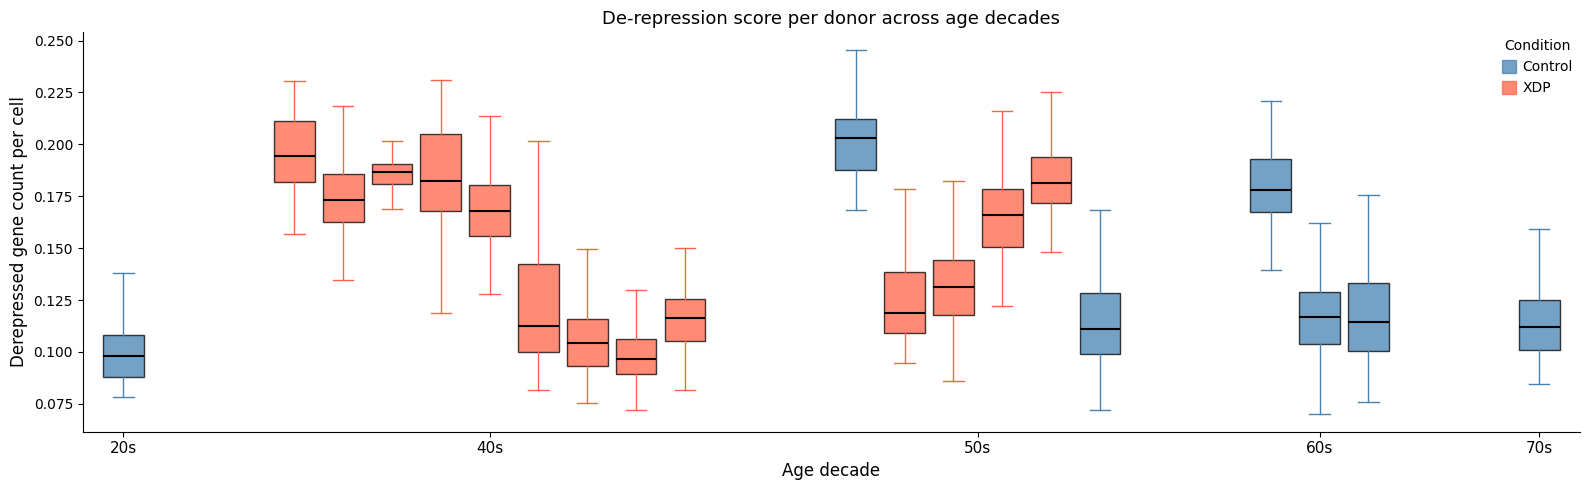

In [175]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Cell-level dataframe with age decade
plot_df = adata_zone.obs[["donor_id", "derepressed_score", AGE, CONTRAST_VARIABLE]].copy()
plot_df["age_decade"] = (plot_df[AGE] // 10 * 10).astype(int).astype(str) + "s"

# Color per condition
palette = {"Control": "steelblue", "XDP": "tomato"}

decades      = sorted(plot_df["age_decade"].unique())
donors_order = plot_df.drop_duplicates("donor_id").sort_values(AGE)

fig, ax = plt.subplots(figsize=(16, 5))

x_pos    = 0
x_ticks  = {}   # decade -> center x position for that group
gap_between_decades  = 1.5
gap_between_donors   = 0.6

for decade in decades:
    decade_df      = plot_df[plot_df["age_decade"] == decade]
    decade_donors  = (
        decade_df.drop_duplicates("donor_id")
        .sort_values(AGE)["donor_id"].tolist()
    )

    decade_start = x_pos
    for donor in decade_donors:
        donor_cells = decade_df[decade_df["donor_id"] == donor]["derepressed_score"].values
        condition   = decade_df[decade_df["donor_id"] == donor][CONTRAST_VARIABLE].iloc[0]
        color       = palette.get(condition, "grey")

        bp = ax.boxplot(
            donor_cells,
            positions   = [x_pos],
            widths      = 0.5,
            patch_artist = True,
            showfliers  = False,
            medianprops = dict(color="black", linewidth=1.5),
            boxprops    = dict(facecolor=color, alpha=0.75),
            whiskerprops= dict(color=color),
            capprops    = dict(color=color),
        )
        x_pos += gap_between_donors

    # Tick at the center of this decade's group
    x_ticks[decade] = (decade_start + x_pos - gap_between_donors) / 2
    x_pos += gap_between_decades   # extra space between decades

ax.set_xticks(list(x_ticks.values()))
ax.set_xticklabels(list(x_ticks.keys()), fontsize=11)
ax.set_xlabel("Age decade", fontsize=12)
ax.set_ylabel("Derepressed gene count per cell", fontsize=12)
ax.set_title("De-repression score per donor across age decades", fontsize=13)

# Legend
legend_patches = [mpatches.Patch(color=c, alpha=0.75, label=l) 
                  for l, c in palette.items()]
ax.legend(handles=legend_patches, title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

# ---